# Cálculo del DQI-I

### Importación de librerías

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import json
import plotly.express as px
from scipy.stats import skew
from tabulate import tabulate
from sklearn.preprocessing import OrdinalEncoder
import random
import warnings
from sklearn.preprocessing import MinMaxScaler,RobustScaler
from sklearn.decomposition import PCA
from sklearn.pipeline import Pipeline
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, silhouette_samples
from matplotlib import cm
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.mixture import GaussianMixture

warnings.filterwarnings('ignore')
sns.set(style="whitegrid")

In [2]:
## Lectura de datos
df_food_general = pd.read_csv('.\Data\Processed\df_food_general.csv',sep=';')
df_dem_final = pd.read_csv('.\Data\Processed\df_dem_final.csv', sep=';')
df_antroph_final = pd.read_csv('.\Data\Processed\df_antroph_final.csv', sep=';')

## Calculo del consumo semanal alimentos y sus componentes

<AxesSubplot: >

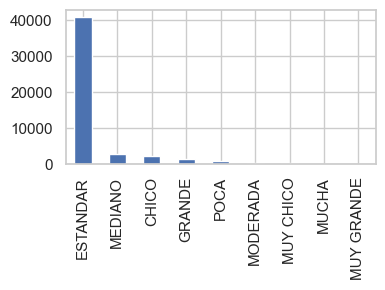

In [3]:
df_base_dqi = df_food_general.copy()
df_base_dqi['tamaño_porcion'].value_counts().plot(kind='bar', figsize=(4, 2))

A continuacion se transforman los valores categóricos de los tamaños de las porciones a valores numéricos, según lo indicado por la Dra. Chuck.

<AxesSubplot: >

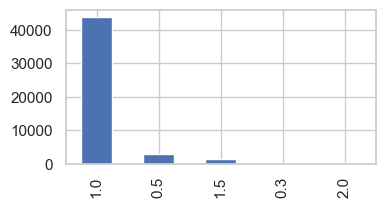

In [4]:
dict_tamano_porcion = {'ESTANDAR':1, 'CHICO':0.5, 'GRANDE':1.5, 'MUY GRANDE':2, 'MEDIANO':1, 'MUY CHICO':0.3,'MUCHA':1.5,'POCA':0.5,'MODERADA':1}
df_base_dqi['tamaño_porcion_num'] = df_base_dqi['tamaño_porcion'].map(dict_tamano_porcion)
df_base_dqi['tamaño_porcion_num'].value_counts().plot(kind='bar', figsize=(4, 2))

In [5]:
## Relleando valores faltantes
df_base_dqi[['dias_consumo', 'veces_al_dia', 'num_porciones', 'tamaño_porcion_num']] = df_base_dqi[['dias_consumo', 'veces_al_dia', 'num_porciones', 'tamaño_porcion_num']].fillna(0)
## Calculo consumo semanal
df_base_dqi['consumo_semanal'] = df_base_dqi['dias_consumo'] * df_base_dqi['veces_al_dia'] * df_base_dqi['num_porciones']*df_base_dqi['tamaño_porcion_num']
# histograma del consumo semanal
fig = px.histogram(df_base_dqi, x='consumo_semanal', nbins=200, title='Histograma del consumo semanal de alimentos')
fig.show()


Hay personas que reportan un consumo semanal de alimentos extremadamente alto, lo cual podría reflejar datos atípicos dado que una persona no podría consumir 350 veces un alimento. Esto se tratará al momento de construir el modelo.

In [6]:
df_componentes = pd.read_excel('./Data/Inputs/nutritional_data.xlsx')
df_componentes.head()

,alimento,porcion_est,porc_est_gm_ml,nombre_bam,calorias_vacias,porcion_bam,energ_kcal,carbohydrt,lipid_tot,protein,...,vit_b12,vit_a_rae,vit_e,vit_d_iu,vit_k,fa_sat,fa_mono,fa_poly,chole,sodio
0,Leche Liconsa,1 vaso (240 ml),240,LECHE LICONSA PROMEDIO,0,100,49.04,4.75,2.36,3.05,...,0.11,48.60,0.00,19.20,0.00,0.800,0.000,0.00,0.000,46.5
1,Otra leche opción A,1 vaso (240 ml),240,LECHE LICONSA PROMEDIO,0,100,49.04,4.75,2.36,3.05,...,0.11,48.60,0.00,19.20,0.00,0.800,0.000,0.00,0.000,38.0
2,Otra leche opción B,1 vaso (240 ml),240,LECHE LICONSA PROMEDIO,0,100,49.04,4.75,2.36,3.05,...,0.11,48.60,0.00,19.20,0.00,0.800,0.000,0.00,0.000,38.0
3,Otra leche opción C,1 vaso (240 ml),240,LECHE LICONSA PROMEDIO,0,100,49.04,4.75,2.36,3.05,...,0.11,48.60,0.00,19.20,0.00,0.800,0.000,0.00,0.000,38.0
4,Leche preparada de sabor (chocolate u otro sabor),1 vaso (240 ml),240,"LECHE CON CHOCOLATE, PREPARACION ESTANDARIZADA",1,100,90.08,12.63,3.05,3.10,...,0.41,171.67,0.64,20.14,0.36,1.952,1.002,0.24,9.049,60.0


Los valores del BAM están sobre porciones de 100 gramos o 100 ml, por lo cual debemos convertir los valores a la porción indicada en la encuesta de alimentos

In [7]:
# convertir valores según porciones
df_componentes['relacion_porcion'] = df_componentes['porc_est_gm_ml'].div(df_componentes['porcion_bam'])
df_componentes.iloc[:, 6:-1] = df_componentes.iloc[:, 6:-1].mul(df_componentes['relacion_porcion'], axis=0)
df_componentes.head()

,alimento,porcion_est,porc_est_gm_ml,nombre_bam,calorias_vacias,porcion_bam,energ_kcal,carbohydrt,lipid_tot,protein,...,vit_a_rae,vit_e,vit_d_iu,vit_k,fa_sat,fa_mono,fa_poly,chole,sodio,relacion_porcion
0,Leche Liconsa,1 vaso (240 ml),240,LECHE LICONSA PROMEDIO,0,100,117.696,11.400,5.664,7.32,...,116.640,0.000,46.080,0.000,1.9200,0.0000,0.000,0.0000,111.6,2.4
1,Otra leche opción A,1 vaso (240 ml),240,LECHE LICONSA PROMEDIO,0,100,117.696,11.400,5.664,7.32,...,116.640,0.000,46.080,0.000,1.9200,0.0000,0.000,0.0000,91.2,2.4
2,Otra leche opción B,1 vaso (240 ml),240,LECHE LICONSA PROMEDIO,0,100,117.696,11.400,5.664,7.32,...,116.640,0.000,46.080,0.000,1.9200,0.0000,0.000,0.0000,91.2,2.4
3,Otra leche opción C,1 vaso (240 ml),240,LECHE LICONSA PROMEDIO,0,100,117.696,11.400,5.664,7.32,...,116.640,0.000,46.080,0.000,1.9200,0.0000,0.000,0.0000,91.2,2.4
4,Leche preparada de sabor (chocolate u otro sabor),1 vaso (240 ml),240,"LECHE CON CHOCOLATE, PREPARACION ESTANDARIZADA",1,100,216.192,30.312,7.320,7.44,...,412.008,1.536,48.336,0.864,4.6848,2.4048,0.576,21.7176,144.0,2.4


Ahora unimos el df de componentes con el de alimentos

In [8]:
# unir los datos de alimentos con los datos nutricionales
df_base_dqi = df_base_dqi.merge(df_componentes, left_on='alimento', right_on='alimento', how='left')
df_base_dqi.isnull().sum()


folio_integrante               0
alimento                       0
porcion_est_x                  0
dias_consumo                   0
especifique_otra_leche    247654
veces_al_dia                   0
tamaño_porcion            201000
num_porciones                  0
porcion_est_num            84224
alimento_grupo                 0
alimento_subgrupo              0
moderacion                  3168
balance                   245876
tamaño_porcion_num             0
consumo_semanal                0
porcion_est_y                  0
porc_est_gm_ml                 0
nombre_bam                     0
calorias_vacias                0
porcion_bam                    0
energ_kcal                     0
carbohydrt                     0
lipid_tot                      0
protein                        0
fiber_td                       0
calcium                        0
iron                           0
ironhem                        0
ironnohem                      0
zinc                           0
vit_c     

Ahora calculamos los componentes nutricionales según el consumo semanal de cada alimento.

In [9]:
# Ahora calculamos los componentes nutricionales según el consumo semanal de cada alimento.
df_base_dqi.iloc[:, 20:-1] = df_base_dqi.iloc[:, 20:-1].mul(df_base_dqi['consumo_semanal'], axis=0)
df_base_dqi.head()

,folio_integrante,alimento,porcion_est_x,dias_consumo,especifique_otra_leche,veces_al_dia,tamaño_porcion,num_porciones,porcion_est_num,alimento_grupo,...,vit_a_rae,vit_e,vit_d_iu,vit_k,fa_sat,fa_mono,fa_poly,chole,sodio,relacion_porcion
0,2022_01001001_01,Leche Liconsa,1 vaso (240 ml),0.0,NaN,0.0,NaN,0.0,1.0,Lacteos,...,0.00,0.0,0.00,0.0,0.00,0.0,0.0,0.0,0.0,2.4
1,2022_01001001_01,Otra leche opción A,1 vaso (240 ml),7.0,Leche entera,2.0,ESTANDAR,1.0,1.0,Lacteos,...,1632.96,0.0,645.12,0.0,26.88,0.0,0.0,0.0,1276.8,2.4
2,2022_01001001_01,Otra leche opción B,1 vaso (240 ml),0.0,NaN,0.0,NaN,0.0,1.0,Lacteos,...,0.00,0.0,0.00,0.0,0.00,0.0,0.0,0.0,0.0,2.4
3,2022_01001001_01,Otra leche opción C,1 vaso (240 ml),0.0,NaN,0.0,NaN,0.0,1.0,Lacteos,...,0.00,0.0,0.00,0.0,0.00,0.0,0.0,0.0,0.0,2.4
4,2022_01001001_01,Leche preparada de sabor (chocolate u otro sabor),1 vaso (240 ml),0.0,NaN,0.0,NaN,0.0,1.0,Lacteos,...,0.00,0.0,0.00,0.0,0.00,0.0,0.0,0.0,0.0,2.4


In [10]:
df_base_dqi.to_csv('./df_base_dqi.csv', sep=';', index=False)

## Calculo de los componentes del DQI

### Calculo del componente de Balance

In [11]:
## calcular los nutrientes consumidos por persona
list_nutrients  = [
                        "energ_kcal", "carbohydrt", "lipid_tot", "protein", "fiber_td",
                        "calcium", "iron", "ironhem", "ironnohem", "zinc",
                        "vit_c", "thiamin", "riboflavin", "niacin", "panto_acid",
                        "vit_b6", "folic_acid", "food_folate", "folate_dfe", "vit_b12",
                        "vit_a_rae", "vit_e", "vit_d_iu", "vit_k", "fa_sat",
                        "fa_mono", "fa_poly", "chole", "sodio"
                    ]
df_nutrients = df_base_dqi.groupby('folio_integrante').sum()[list_nutrients]
df_nutrients.head()


,energ_kcal,carbohydrt,lipid_tot,protein,fiber_td,calcium,iron,ironhem,ironnohem,zinc,...,vit_b12,vit_a_rae,vit_e,vit_d_iu,vit_k,fa_sat,fa_mono,fa_poly,chole,sodio
folio_integrante,,,,,,,,,,,,,,,,,,,,,
2022_01001001_01,7942.748400,1053.768410,316.780600,299.807050,130.912750,7933.4173,67.57558,2.0320,38.68308,53.623690,...,7.7740,3269.94550,15.570750,855.3610,396.57300,110.002815,87.380040,47.409360,436.311900,5091.5500
2022_01001007_04,10188.514200,1552.413200,317.152900,356.773300,85.063300,10420.9000,79.81630,2.1140,39.77830,74.473800,...,18.1695,5801.64000,16.814090,1630.9250,134.32660,124.947350,73.312730,27.450590,1171.179550,8193.4400
2022_01001016_13,5907.336000,664.798800,285.823600,190.180800,47.036500,3528.2880,39.58570,1.1180,19.63820,33.327000,...,7.5615,1553.66600,9.025000,565.9590,66.69300,115.686740,84.363340,37.248810,1014.657600,5336.4200
2022_01001028_04,11984.458475,1578.962350,451.073700,471.864675,172.392750,7778.0270,85.94970,5.2282,66.92500,68.392875,...,17.8673,7965.16950,45.531000,1006.2060,984.85625,168.886327,165.511002,78.111185,2838.916150,11323.7060
2022_01001028_06,5802.271275,870.090775,185.723627,202.725924,122.760165,3337.8500,43.15056,0.7647,36.26686,30.666847,...,8.9255,2654.57385,23.628128,647.1865,441.90800,64.196774,77.498861,34.315620,2032.703262,6629.1974


A continuación se calcula el "Macronutrient ratio"

In [12]:
# Calcular macronutrients ratio por macronutriente
df_nutrients['carbohydrt_ratio'] = (df_nutrients['carbohydrt'] *4).div(df_nutrients['carbohydrt']*4 + df_nutrients['lipid_tot']*9 + df_nutrients['protein']*4)
df_nutrients['lipid_tot_ratio'] = (df_nutrients['lipid_tot'] *9).div(df_nutrients['carbohydrt']*4 + df_nutrients['lipid_tot']*9 + df_nutrients['protein']*4)
df_nutrients['protein_ratio'] = (df_nutrients['protein'] *4).div(df_nutrients['carbohydrt']*4 + df_nutrients['lipid_tot']*9 + df_nutrients['protein']*4)
df_nutrients.head()


,energ_kcal,carbohydrt,lipid_tot,protein,fiber_td,calcium,iron,ironhem,ironnohem,zinc,...,vit_d_iu,vit_k,fa_sat,fa_mono,fa_poly,chole,sodio,carbohydrt_ratio,lipid_tot_ratio,protein_ratio
folio_integrante,,,,,,,,,,,,,,,,,,,,,
2022_01001001_01,7942.748400,1053.768410,316.780600,299.807050,130.912750,7933.4173,67.57558,2.0320,38.68308,53.623690,...,855.3610,396.57300,110.002815,87.380040,47.409360,436.311900,5091.5500,0.509971,0.344938,0.145091
2022_01001007_04,10188.514200,1552.413200,317.152900,356.773300,85.063300,10420.9000,79.81630,2.1140,39.77830,74.473800,...,1630.9250,134.32660,124.947350,73.312730,27.450590,1171.179550,8193.4400,0.591896,0.272075,0.136029
2022_01001016_13,5907.336000,664.798800,285.823600,190.180800,47.036500,3528.2880,39.58570,1.1180,19.63820,33.327000,...,565.9590,66.69300,115.686740,84.363340,37.248810,1014.657600,5336.4200,0.443766,0.429284,0.126949
2022_01001028_04,11984.458475,1578.962350,451.073700,471.864675,172.392750,7778.0270,85.94970,5.2282,66.92500,68.392875,...,1006.2060,984.85625,168.886327,165.511002,78.111185,2838.916150,11323.7060,0.515034,0.331051,0.153915
2022_01001028_06,5802.271275,870.090775,185.723627,202.725924,122.760165,3337.8500,43.15056,0.7647,36.26686,30.666847,...,647.1865,441.90800,64.196774,77.498861,34.315620,2032.703262,6629.1974,0.583681,0.280324,0.135994


A continuación se calculan los puntos de DQI para el componente de macronutrientes dentro del componente de 'Overall Balance' del DQI.

In [13]:
# calcular puntos del DQI para el componente de macronutrientes
def evaluate_macronutrients(df):
    dqi_points = 0
    if 0.55 <= df['carbohydrt_ratio'] <= 0.65 and 0.10 <= df['protein_ratio'] <= 0.15 and 0.15 <= df['lipid_tot_ratio'] <= 0.25:
        dqi_points = 6
    elif 0.52 <= df['carbohydrt_ratio'] <= 0.68 and 0.09 <= df['protein_ratio'] <= 0.16 and 0.13 <= df['lipid_tot_ratio'] <= 0.27:
        dqi_points = 4
    elif 0.50 <= df['carbohydrt_ratio'] <= 0.70 and 0.08 <= df['protein_ratio'] <= 0.17 and 0.12 <= df['lipid_tot_ratio'] <= 0.30:
        dqi_points = 2
    return dqi_points

df_nutrients['macronutrients_dqi'] = df_nutrients.apply(evaluate_macronutrients, axis=1)
df_nutrients.head()

,energ_kcal,carbohydrt,lipid_tot,protein,fiber_td,calcium,iron,ironhem,ironnohem,zinc,...,vit_k,fa_sat,fa_mono,fa_poly,chole,sodio,carbohydrt_ratio,lipid_tot_ratio,protein_ratio,macronutrients_dqi
folio_integrante,,,,,,,,,,,,,,,,,,,,,
2022_01001001_01,7942.748400,1053.768410,316.780600,299.807050,130.912750,7933.4173,67.57558,2.0320,38.68308,53.623690,...,396.57300,110.002815,87.380040,47.409360,436.311900,5091.5500,0.509971,0.344938,0.145091,0
2022_01001007_04,10188.514200,1552.413200,317.152900,356.773300,85.063300,10420.9000,79.81630,2.1140,39.77830,74.473800,...,134.32660,124.947350,73.312730,27.450590,1171.179550,8193.4400,0.591896,0.272075,0.136029,2
2022_01001016_13,5907.336000,664.798800,285.823600,190.180800,47.036500,3528.2880,39.58570,1.1180,19.63820,33.327000,...,66.69300,115.686740,84.363340,37.248810,1014.657600,5336.4200,0.443766,0.429284,0.126949,0
2022_01001028_04,11984.458475,1578.962350,451.073700,471.864675,172.392750,7778.0270,85.94970,5.2282,66.92500,68.392875,...,984.85625,168.886327,165.511002,78.111185,2838.916150,11323.7060,0.515034,0.331051,0.153915,0
2022_01001028_06,5802.271275,870.090775,185.723627,202.725924,122.760165,3337.8500,43.15056,0.7647,36.26686,30.666847,...,441.90800,64.196774,77.498861,34.315620,2032.703262,6629.1974,0.583681,0.280324,0.135994,2


A continuación se calculan los ratios de ácidos grasos saturados, monoinsaturados y poliinsaturados. (PUFA:MUFA:SFA)

In [14]:
# A continuación se calculan los ratios de ácidos grasos saturados, monoinsaturados y poliinsaturados. (PUFA:MUFA:SFA)
df_nutrients['poly_ratio'] = df_nutrients['fa_poly'].div(df_nutrients['fa_sat'])
df_nutrients['mono_ratio'] = df_nutrients['fa_mono'].div(df_nutrients['fa_sat'])
df_nutrients.head()

,energ_kcal,carbohydrt,lipid_tot,protein,fiber_td,calcium,iron,ironhem,ironnohem,zinc,...,fa_mono,fa_poly,chole,sodio,carbohydrt_ratio,lipid_tot_ratio,protein_ratio,macronutrients_dqi,poly_ratio,mono_ratio
folio_integrante,,,,,,,,,,,,,,,,,,,,,
2022_01001001_01,7942.748400,1053.768410,316.780600,299.807050,130.912750,7933.4173,67.57558,2.0320,38.68308,53.623690,...,87.380040,47.409360,436.311900,5091.5500,0.509971,0.344938,0.145091,0,0.430983,0.794344
2022_01001007_04,10188.514200,1552.413200,317.152900,356.773300,85.063300,10420.9000,79.81630,2.1140,39.77830,74.473800,...,73.312730,27.450590,1171.179550,8193.4400,0.591896,0.272075,0.136029,2,0.219697,0.586749
2022_01001016_13,5907.336000,664.798800,285.823600,190.180800,47.036500,3528.2880,39.58570,1.1180,19.63820,33.327000,...,84.363340,37.248810,1014.657600,5336.4200,0.443766,0.429284,0.126949,0,0.321980,0.729239
2022_01001028_04,11984.458475,1578.962350,451.073700,471.864675,172.392750,7778.0270,85.94970,5.2282,66.92500,68.392875,...,165.511002,78.111185,2838.916150,11323.7060,0.515034,0.331051,0.153915,0,0.462507,0.980014
2022_01001028_06,5802.271275,870.090775,185.723627,202.725924,122.760165,3337.8500,43.15056,0.7647,36.26686,30.666847,...,77.498861,34.315620,2032.703262,6629.1974,0.583681,0.280324,0.135994,2,0.534538,1.207208


A continuación se calculan los puntos de DQI para el componente de ratio de ácidos grasos dentro del componente de 'Overall Balance' del DQI.

In [15]:
# calcular puntos del DQI para el componente de ácidos grasos
def evaluate_fatty_acids(df):
    dqi_points = 0
    if 1 <= df['poly_ratio'] <= 1.5 and 1 <= df['mono_ratio'] <= 1.5:
        dqi_points = 4
    elif 0.8 <= df['poly_ratio'] <= 1.7 and 0.8 <= df['mono_ratio'] <= 1.7:
        dqi_points = 2

    return dqi_points

df_nutrients['fatty_acids_dqi'] = df_nutrients.apply(evaluate_fatty_acids, axis=1)
df_nutrients.head()


,energ_kcal,carbohydrt,lipid_tot,protein,fiber_td,calcium,iron,ironhem,ironnohem,zinc,...,fa_poly,chole,sodio,carbohydrt_ratio,lipid_tot_ratio,protein_ratio,macronutrients_dqi,poly_ratio,mono_ratio,fatty_acids_dqi
folio_integrante,,,,,,,,,,,,,,,,,,,,,
2022_01001001_01,7942.748400,1053.768410,316.780600,299.807050,130.912750,7933.4173,67.57558,2.0320,38.68308,53.623690,...,47.409360,436.311900,5091.5500,0.509971,0.344938,0.145091,0,0.430983,0.794344,0
2022_01001007_04,10188.514200,1552.413200,317.152900,356.773300,85.063300,10420.9000,79.81630,2.1140,39.77830,74.473800,...,27.450590,1171.179550,8193.4400,0.591896,0.272075,0.136029,2,0.219697,0.586749,0
2022_01001016_13,5907.336000,664.798800,285.823600,190.180800,47.036500,3528.2880,39.58570,1.1180,19.63820,33.327000,...,37.248810,1014.657600,5336.4200,0.443766,0.429284,0.126949,0,0.321980,0.729239,0
2022_01001028_04,11984.458475,1578.962350,451.073700,471.864675,172.392750,7778.0270,85.94970,5.2282,66.92500,68.392875,...,78.111185,2838.916150,11323.7060,0.515034,0.331051,0.153915,0,0.462507,0.980014,0
2022_01001028_06,5802.271275,870.090775,185.723627,202.725924,122.760165,3337.8500,43.15056,0.7647,36.26686,30.666847,...,34.315620,2032.703262,6629.1974,0.583681,0.280324,0.135994,2,0.534538,1.207208,0


<AxesSubplot: title={'center': 'Distribución de puntos de DQI para el componente de balance'}>

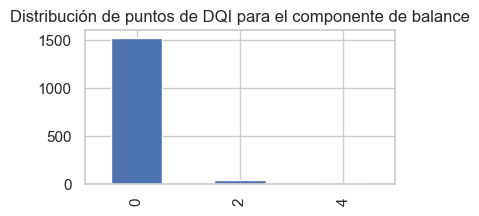

In [16]:
df_nutrients['fatty_acids_dqi'].value_counts().sort_index().plot(kind='bar', figsize=(4, 2), title='Distribución de puntos de DQI para el componente de balance')

<AxesSubplot: title={'center': 'Distribución de puntos de DQI para el componente de balance'}>

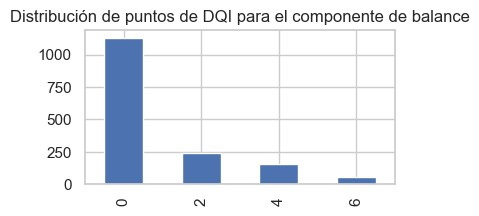

In [17]:
df_nutrients['macronutrients_dqi'].value_counts().sort_index().plot(kind='bar', figsize=(4, 2), title='Distribución de puntos de DQI para el componente de balance')

<AxesSubplot: title={'center': 'Distribución de puntos de DQI para el componente de balance'}>

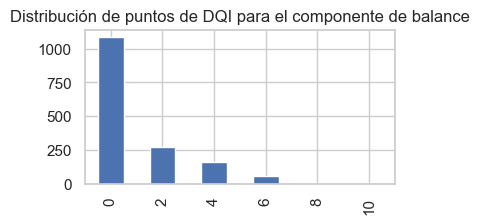

In [18]:
df_nutrients['balance_dqi'] = df_nutrients['fatty_acids_dqi'] + df_nutrients['macronutrients_dqi']

df_nutrients['balance_dqi'].value_counts().sort_index().plot(kind='bar', figsize=(4, 2), title='Distribución de puntos de DQI para el componente de balance')

### Cálculo del componente de Moderation

Primero se calcula el número de calorias correspondientes a alimentos clasificados como "Calorias vacias" para cada persona.

In [19]:
df_empty_calories = df_base_dqi[df_base_dqi['calorias_vacias'] == 1].groupby('folio_integrante').sum()['energ_kcal']
df_empty_calories.rename('empty_calories', inplace=True)
df_nutrients = df_nutrients.merge(df_empty_calories, left_on='folio_integrante', right_index=True, how='left')
df_nutrients['empty_calories'].fillna(0, inplace=True)
df_nutrients.head()



,energ_kcal,carbohydrt,lipid_tot,protein,fiber_td,calcium,iron,ironhem,ironnohem,zinc,...,sodio,carbohydrt_ratio,lipid_tot_ratio,protein_ratio,macronutrients_dqi,poly_ratio,mono_ratio,fatty_acids_dqi,balance_dqi,empty_calories
folio_integrante,,,,,,,,,,,,,,,,,,,,,
2022_01001001_01,7942.748400,1053.768410,316.780600,299.807050,130.912750,7933.4173,67.57558,2.0320,38.68308,53.623690,...,5091.5500,0.509971,0.344938,0.145091,0,0.430983,0.794344,0,0,1345.2704
2022_01001007_04,10188.514200,1552.413200,317.152900,356.773300,85.063300,10420.9000,79.81630,2.1140,39.77830,74.473800,...,8193.4400,0.591896,0.272075,0.136029,2,0.219697,0.586749,0,2,1247.7072
2022_01001016_13,5907.336000,664.798800,285.823600,190.180800,47.036500,3528.2880,39.58570,1.1180,19.63820,33.327000,...,5336.4200,0.443766,0.429284,0.126949,0,0.321980,0.729239,0,0,2009.0000
2022_01001028_04,11984.458475,1578.962350,451.073700,471.864675,172.392750,7778.0270,85.94970,5.2282,66.92500,68.392875,...,11323.7060,0.515034,0.331051,0.153915,0,0.462507,0.980014,0,0,863.9076
2022_01001028_06,5802.271275,870.090775,185.723627,202.725924,122.760165,3337.8500,43.15056,0.7647,36.26686,30.666847,...,6629.1974,0.583681,0.280324,0.135994,2,0.534538,1.207208,0,2,310.5822


Se calcula el % de calorías vacías consumido por cada persona

In [20]:
df_nutrients['porc_empty_calories'] = df_nutrients['empty_calories'].div(df_nutrients['energ_kcal'])

Se calcula el valor del DQI-I según el % de calorías vacías consumidas por cada persona

<AxesSubplot: title={'center': 'Distribución de puntos de DQI para el componente de calorías vacías'}>

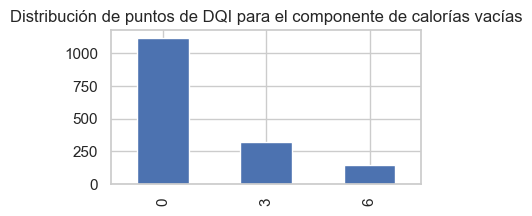

In [21]:

# Cálculo del porcentaje de calorías vacías
def calculate_empty_calories_dqi(row):

    # Evaluar según la imagen proporcionada:
    if row['porc_empty_calories'] <= 0.03:  # Menos del 3% de calorías vacías
        return 6
    elif 0.03 < row['porc_empty_calories']  <= 0.10:  # Entre 3% y 10%
        return 3
    else:  # Más del 10% de calorías vacías
        return 0


# Aplicamos la función a cada fila de datos
df_nutrients['empty_calories_dqi'] = df_nutrients.apply(calculate_empty_calories_dqi, axis=1)

df_nutrients['empty_calories_dqi'].value_counts().sort_values(ascending=False).plot(kind='bar', figsize=(4, 2), title='Distribución de puntos de DQI para el componente de calorías vacías')


A continuación se calculan los porcentajes de grasas totaless y saturadas que se usarán para calcular los otros componentes del DQI para Adecuacy

In [22]:
df_nutrients['fat_percentage'] = (df_nutrients['lipid_tot']*9).div(df_nutrients['energ_kcal'])
df_nutrients['fa_sat_percentage'] = (df_nutrients['fa_sat']*9).div(df_nutrients['energ_kcal'])

In [23]:
def calculate_total_fat_dqi(row):

    if row['fat_percentage'] <= 0.20:
        return 6
    elif row['fat_percentage'] > 0.30:
        return 0
    else:
        return 3

def calculate_saturated_fat_dqi(row):
    
        if row['fa_sat_percentage'] <= 0.07:
            return 6
        elif row['fa_sat_percentage'] > 0.10:
            return 0
        else:
            return 3

def calculate_cholesterol_dqi(row):
       
    colesterol_diario = row['chole'] / 7  # Dividimos el colesterol de 7 días para obtener el promedio diario

    # Aplicamos la lógica para el DQI basado en el consumo diario
    if colesterol_diario <= 300:
        return 6
    elif colesterol_diario > 400:
        return 0
    else:
        return 3

def calculate_sodium_dqi(row):
        
        sodio_diario = row['sodio'] / 7  # Dividimos el sodio de 7 días para obtener el promedio diario
    
        # Aplicamos la lógica para el DQI basado en el consumo diario
        if sodio_diario <= 2400:
            return 6
        elif sodio_diario > 3600:
            return 0
        else:
            return 3

df_nutrients['total_fat_dqi'] = df_nutrients.apply(calculate_total_fat_dqi, axis=1)
df_nutrients['saturated_fat_dqi'] = df_nutrients.apply(calculate_saturated_fat_dqi, axis=1)
df_nutrients['cholesterol_dqi'] = df_nutrients.apply(calculate_cholesterol_dqi, axis=1)
df_nutrients['sodium_dqi'] = df_nutrients.apply(calculate_sodium_dqi, axis=1)


<AxesSubplot: title={'center': 'Distribución de puntos de DQI para el componente de grasa total'}>

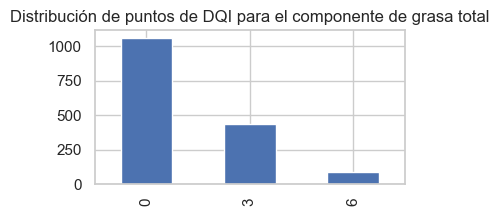

In [24]:
df_nutrients['total_fat_dqi'].value_counts().sort_values(ascending=False).plot(kind='bar', figsize=(4, 2), title='Distribución de puntos de DQI para el componente de grasa total')

<AxesSubplot: title={'center': 'Distribución de puntos de DQI para el componente de grasa saturada'}>

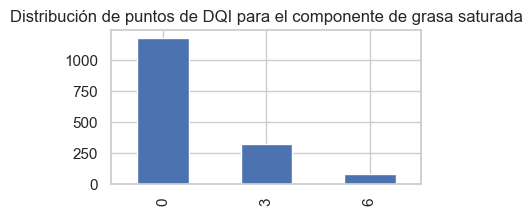

In [25]:
df_nutrients['saturated_fat_dqi'].value_counts().sort_values(ascending=False).plot(kind='bar', figsize=(4, 2), title='Distribución de puntos de DQI para el componente de grasa saturada')

<AxesSubplot: title={'center': 'Distribución de puntos de DQI para el componente de colesterol'}>

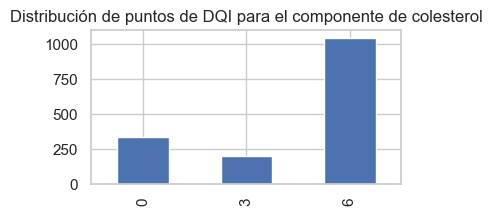

In [26]:
df_nutrients['cholesterol_dqi'].value_counts().sort_index(ascending=True).plot(kind='bar', figsize=(4, 2), title='Distribución de puntos de DQI para el componente de colesterol')

<AxesSubplot: title={'center': 'Distribución de puntos de DQI para el componente de sodio'}>

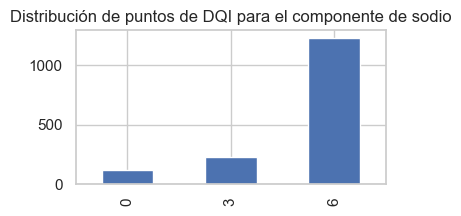

In [27]:
df_nutrients['sodium_dqi'].value_counts().sort_index(ascending=True).plot(kind='bar', figsize=(4, 2), title='Distribución de puntos de DQI para el componente de sodio')

En la siguiente gráfica se muestran los resultados en gráfica de barra ordenados por frecuencia de los puntos obtenidos de DQI por la variable moderation que puede ir de 0 a 30. 

<AxesSubplot: title={'center': 'Distribución de puntos de DQI para el componente de Moderation'}>

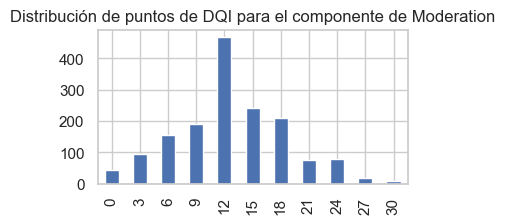

In [28]:
# En este momento faltan los datos de sodio y calorías vacías para calcular por completo el componente de Moderation.
df_nutrients['moderation_dqi'] = df_nutrients['empty_calories_dqi'] + df_nutrients['total_fat_dqi'] + df_nutrients['saturated_fat_dqi'] + df_nutrients['cholesterol_dqi'] + df_nutrients['sodium_dqi']
df_nutrients['moderation_dqi'].value_counts().sort_index(ascending=True).plot(kind='bar', figsize=(4, 2), title='Distribución de puntos de DQI para el componente de Moderation')

### Calculo del componente Variety Food Groups


Definimos los datos que se necesitan para los calculos de Variety - food groups, Variety - protein sources y Adequacy


Leemos la información de a qué grupo pertenece cada alimento según la segmentación en el DQI-I

In [29]:
df_food_groups = pd.read_excel('./Data/Inputs/grupos_alimentos.xlsx')
df_food_groups.head()

,alimento,alimento_grupo,alimento_subgrupo
0,Leche Liconsa,Lacteos/Frijol,Lacteos
1,Otra leche opción A,Lacteos/Frijol,Lacteos
2,Otra leche opción B,Lacteos/Frijol,Lacteos
3,Otra leche opción C,Lacteos/Frijol,Lacteos
4,Leche preparada de sabor (chocolate u otro sabor),Lacteos/Frijol,Lacteos


In [30]:
df_food_general.drop(columns=['alimento_grupo','alimento_subgrupo','moderacion','balance'], inplace=True)

In [31]:
df_food_general = df_food_general.merge(df_food_groups, on='alimento', how='left')
df_food_general.head()

,folio_integrante,alimento,porcion_est,dias_consumo,especifique_otra_leche,veces_al_dia,tamaño_porcion,num_porciones,porcion_est_num,alimento_grupo,alimento_subgrupo
0,2022_01001001_01,Leche Liconsa,1 vaso (240 ml),0.0,NaN,NaN,NaN,NaN,1.0,Lacteos/Frijol,Lacteos
1,2022_01001001_01,Otra leche opción A,1 vaso (240 ml),7.0,Leche entera,2.0,ESTANDAR,1.0,1.0,Lacteos/Frijol,Lacteos
2,2022_01001001_01,Otra leche opción B,1 vaso (240 ml),0.0,NaN,NaN,NaN,NaN,1.0,Lacteos/Frijol,Lacteos
3,2022_01001001_01,Otra leche opción C,1 vaso (240 ml),0.0,NaN,NaN,NaN,NaN,1.0,Lacteos/Frijol,Lacteos
4,2022_01001001_01,Leche preparada de sabor (chocolate u otro sabor),1 vaso (240 ml),0.0,NaN,NaN,NaN,NaN,1.0,Lacteos/Frijol,Lacteos


Se calcula el consumo semanal de cada alimento

In [32]:
dict_tamano_porcion = {'ESTANDAR':1, 'CHICO':0.5, 'GRANDE':1.5, 'MUY GRANDE':2, 'MEDIANO':1, 'MUY CHICO':0.3,'MUCHA':1.5,'POCA':0.5,'MODERADA':1}
df_food_general['tamaño_porcion_num'] = df_food_general['tamaño_porcion'].map(dict_tamano_porcion)
## Relleando valores faltantes
df_food_general[['dias_consumo', 'veces_al_dia', 'num_porciones', 'tamaño_porcion_num']] = df_food_general[['dias_consumo', 'veces_al_dia', 'num_porciones', 'tamaño_porcion_num']].fillna(0)
## Calculo consumo semanal
df_food_general['consumo_semanal'] = df_food_general['dias_consumo'] * df_food_general['veces_al_dia'] * df_food_general['num_porciones']*df_food_general['tamaño_porcion_num']

A continuación se calculan las porciones de cada grupo por dia por persona

In [33]:
df_group_servings = df_food_general.pivot_table(index='folio_integrante', columns='alimento_grupo', values='consumo_semanal', aggfunc='sum')
df_group_servings.fillna(0, inplace=True)
df_group_servings = df_group_servings/7
df_group_servings.head()

alimento_grupo,Aceites y Grasas,Azucares,Cereales,Frutas,Lacteos/Frijol,Misceláneos,Proteina,Unknown,Verduras
folio_integrante,,,,,,,,,
2022_01001001_01,1.000000,5.187143,0.285714,3.071429,3.785714,9.285714,1.142857,0.0,4.571429
2022_01001007_04,0.000000,5.571429,0.547143,0.571429,3.714286,9.071429,0.928571,0.0,1.214286
2022_01001016_13,0.000000,0.000000,1.285714,0.428571,2.714286,2.000000,0.857143,0.0,0.428571
2022_01001028_04,1.214286,3.857143,0.714286,1.821429,2.500000,7.657143,2.428571,0.0,8.714286
2022_01001028_06,0.571429,1.464286,0.285714,2.772857,1.535714,3.692857,1.428571,0.0,4.178571


In [34]:
# Se hace drop a columna Unkonwn que se generó en el proceso de pivot_table con df_food_general
df_group_servings.drop(columns='Unknown', inplace=True)

In [35]:
# añadir la palabra "porciones de " al nombre de cada columna
df_nutrients = df_nutrients.merge(df_group_servings, left_on='folio_integrante', right_index=True, how='left')
df_nutrients.head()

,energ_kcal,carbohydrt,lipid_tot,protein,fiber_td,calcium,iron,ironhem,ironnohem,zinc,...,sodium_dqi,moderation_dqi,Aceites y Grasas,Azucares,Cereales,Frutas,Lacteos/Frijol,Misceláneos,Proteina,Verduras
folio_integrante,,,,,,,,,,,,,,,,,,,,,
2022_01001001_01,7942.748400,1053.768410,316.780600,299.807050,130.912750,7933.4173,67.57558,2.0320,38.68308,53.623690,...,6,12,1.000000,5.187143,0.285714,3.071429,3.785714,9.285714,1.142857,4.571429
2022_01001007_04,10188.514200,1552.413200,317.152900,356.773300,85.063300,10420.9000,79.81630,2.1140,39.77830,74.473800,...,6,15,0.000000,5.571429,0.547143,0.571429,3.714286,9.071429,0.928571,1.214286
2022_01001016_13,5907.336000,664.798800,285.823600,190.180800,47.036500,3528.2880,39.58570,1.1180,19.63820,33.327000,...,6,12,0.000000,0.000000,1.285714,0.428571,2.714286,2.000000,0.857143,0.428571
2022_01001028_04,11984.458475,1578.962350,451.073700,471.864675,172.392750,7778.0270,85.94970,5.2282,66.92500,68.392875,...,6,9,1.214286,3.857143,0.714286,1.821429,2.500000,7.657143,2.428571,8.714286
2022_01001028_06,5802.271275,870.090775,185.723627,202.725924,122.760165,3337.8500,43.15056,0.7647,36.26686,30.666847,...,6,21,0.571429,1.464286,0.285714,2.772857,1.535714,3.692857,1.428571,4.178571


Según el DQI-I una persona debe consumir los 5 grupos de alimentos diariamente para obtener el puntaje máximo, por lo cual consideramos que un grupo hace parte de la dieta de la persona si el número de porciones consumidas en promedio por día es mayor o igual a 1, con base en esto se calculará el DQI para los grupos de alimentos

<AxesSubplot: title={'center': 'Distribución de puntos de DQI para el componente de grupos de alimentos'}>

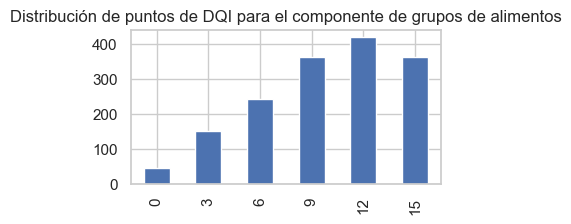

In [36]:
dqi_food_groups = ['Proteina', 'Lacteos/Frijol', 'Cereales', 'Verduras', 'Frutas']
def calculate_dqi_food_groups(row,columns):
    # contar el numero de columnas mayores a 1 en la fila
    groups_consumed_daily = 0
    for column in columns:
        if row[column] >= 1:
            groups_consumed_daily += 1
    
    if groups_consumed_daily == 5:
        return 15
    elif groups_consumed_daily == 4:
        return 12
    elif groups_consumed_daily == 3:
        return 9
    elif groups_consumed_daily == 2:
        return 6
    elif groups_consumed_daily == 1:
        return 3
    else:
        return 0
    
df_nutrients['dqi_food_groups'] = df_nutrients.apply(calculate_dqi_food_groups, axis=1, columns=dqi_food_groups)
df_nutrients['dqi_food_groups'].value_counts().sort_index(ascending=True).plot(kind='bar', figsize=(4, 2), title='Distribución de puntos de DQI para el componente de grupos de alimentos')


### Calculo del componente Variety Protein Groups

Ahora se evalua la variedad al interior del grupo de la proteina

In [37]:
dqi_protein_sources = ['Carne', 'Pollo','Huevo', 'Pescado', 'Lacteos', 'Frijoles']
df_food_general_protein = df_food_general[df_food_general['alimento_subgrupo'].isin(dqi_protein_sources)]
df_food_general_protein['alimento_subgrupo'].value_counts()

Lacteos     28868
Carne       10843
Frijoles     9860
Pescado      6336
Pollo        4752
Huevo        3168
Name: alimento_subgrupo, dtype: int64

Se calculan las porciones promedio por día de cada subgrupo

In [38]:
df_group_servings_protein = df_food_general_protein.pivot_table(index='folio_integrante', columns='alimento_subgrupo', values='consumo_semanal', aggfunc='sum')
df_group_servings_protein.fillna(0, inplace=True)
df_group_servings_protein = df_group_servings_protein/7
df_group_servings_protein.head()

alimento_subgrupo,Carne,Frijoles,Huevo,Lacteos,Pescado,Pollo
folio_integrante,,,,,,
2022_01001001_01,0.714286,1.500000,0.000000,2.285714,0.142857,0.285714
2022_01001007_04,0.285714,0.214286,0.428571,3.500000,0.000000,0.214286
2022_01001016_13,0.285714,1.000000,0.428571,1.714286,0.000000,0.000000
2022_01001028_04,0.571429,0.571429,1.142857,1.928571,0.000000,0.285714
2022_01001028_06,0.178571,1.000000,1.142857,0.535714,0.000000,0.107143


In [39]:
# agregar la palabra "subgrupo de " al nombre de cada columna de df_group_servings_protein
df_group_servings_protein.columns = ['subgrupo de ' + column for column in df_group_servings_protein.columns]
df_group_servings_protein.head()

,subgrupo de Carne,subgrupo de Frijoles,subgrupo de Huevo,subgrupo de Lacteos,subgrupo de Pescado,subgrupo de Pollo
folio_integrante,,,,,,
2022_01001001_01,0.714286,1.500000,0.000000,2.285714,0.142857,0.285714
2022_01001007_04,0.285714,0.214286,0.428571,3.500000,0.000000,0.214286
2022_01001016_13,0.285714,1.000000,0.428571,1.714286,0.000000,0.000000
2022_01001028_04,0.571429,0.571429,1.142857,1.928571,0.000000,0.285714
2022_01001028_06,0.178571,1.000000,1.142857,0.535714,0.000000,0.107143


Según el DQI-I una persona debe consumir los 6 subgrupos de proteina con al menos media porción diariamente para obtener el puntaje máximo, por lo cual consideramos que un grupo hace parte de la dieta de la persona si el número de porciones 0.5, con base en esto se calculará el DQI para los subgrupos de proteina.

In [40]:
df_nutrients = df_nutrients.merge(df_group_servings_protein, left_on='folio_integrante', right_index=True, how='left')
df_nutrients.head()

,energ_kcal,carbohydrt,lipid_tot,protein,fiber_td,calcium,iron,ironhem,ironnohem,zinc,...,Misceláneos,Proteina,Verduras,dqi_food_groups,subgrupo de Carne,subgrupo de Frijoles,subgrupo de Huevo,subgrupo de Lacteos,subgrupo de Pescado,subgrupo de Pollo
folio_integrante,,,,,,,,,,,,,,,,,,,,,
2022_01001001_01,7942.748400,1053.768410,316.780600,299.807050,130.912750,7933.4173,67.57558,2.0320,38.68308,53.623690,...,9.285714,1.142857,4.571429,12,0.714286,1.500000,0.000000,2.285714,0.142857,0.285714
2022_01001007_04,10188.514200,1552.413200,317.152900,356.773300,85.063300,10420.9000,79.81630,2.1140,39.77830,74.473800,...,9.071429,0.928571,1.214286,6,0.285714,0.214286,0.428571,3.500000,0.000000,0.214286
2022_01001016_13,5907.336000,664.798800,285.823600,190.180800,47.036500,3528.2880,39.58570,1.1180,19.63820,33.327000,...,2.000000,0.857143,0.428571,6,0.285714,1.000000,0.428571,1.714286,0.000000,0.000000
2022_01001028_04,11984.458475,1578.962350,451.073700,471.864675,172.392750,7778.0270,85.94970,5.2282,66.92500,68.392875,...,7.657143,2.428571,8.714286,12,0.571429,0.571429,1.142857,1.928571,0.000000,0.285714
2022_01001028_06,5802.271275,870.090775,185.723627,202.725924,122.760165,3337.8500,43.15056,0.7647,36.26686,30.666847,...,3.692857,1.428571,4.178571,12,0.178571,1.000000,1.142857,0.535714,0.000000,0.107143


<AxesSubplot: title={'center': 'Distribución de puntos de DQI para el componente de fuentes de proteínas'}>

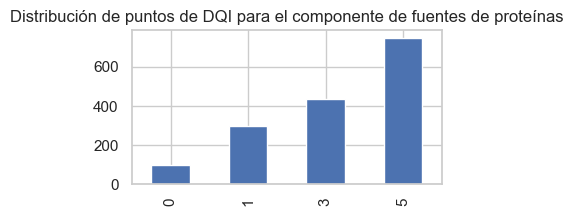

In [41]:

def calculate_dqi_food_groups(row, dqi_protein_sources):
    # contar el numero de columnas mayores a 0.5 en la fila
    groups_consumed_daily = 0
    for column in dqi_protein_sources:
        if row[column] >= 0.5:
            groups_consumed_daily += 1
    if groups_consumed_daily >= 3:
        return 5
    elif groups_consumed_daily == 2:
        return 3
    elif groups_consumed_daily == 1:
        return 1
    else:
        return 0

df_nutrients['dqi_protein_sources'] = df_nutrients.apply(calculate_dqi_food_groups, axis=1, dqi_protein_sources=df_group_servings_protein.columns)
df_nutrients['dqi_protein_sources'].value_counts().sort_index(ascending=True).plot(kind='bar', figsize=(4, 2), title='Distribución de puntos de DQI para el componente de fuentes de proteínas')

<AxesSubplot: title={'center': 'Distribución de puntos de DQI para el componente de variedad'}>

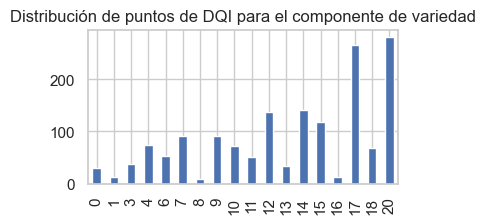

In [42]:
df_nutrients['variety_dqi'] = df_nutrients['dqi_food_groups'] + df_nutrients['dqi_protein_sources']
df_nutrients['variety_dqi'].value_counts().sort_index(ascending=True).plot(kind='bar', figsize=(4, 2), title='Distribución de puntos de DQI para el componente de variedad')

### Calculo del componente Adequacy


Se realizarán los cálculos del adecuacy suponiendo una dieta de todos los individuos de 1700 calorias diarias

Text(0.5, 1.0, 'Histograma de consumo diario de calorías')

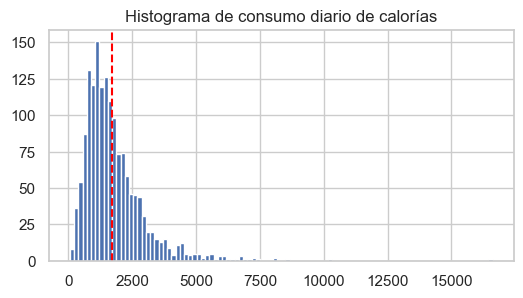

In [43]:
# Generar un histograma del numero de calorías consumidas por persona, marcando el valor de 1700 como referencia
plt.figure(figsize=(6, 3))
plt.hist(df_nutrients['energ_kcal']/7, bins=100)
plt.axvline(x=1700, color='red', linestyle='--')
plt.title('Histograma de consumo diario de calorías')


Para las frutas el valor de referencia es de 2 porciones por día, para las frutas 3 y para los cereales 6.

In [44]:
def calculate_adecucy_groups(row, group ,reference):
    pertentage_intake = row[group] / reference
    if pertentage_intake >= 1:
        return 5
    elif pertentage_intake >= 0.8:
        return 4
    elif pertentage_intake >= 0.6:
        return 3
    elif pertentage_intake >= 0.4:
        return 2
    elif pertentage_intake >= 0.2:
        return 1
    else:
        return 0

df_nutrients['dqi_adequacy_fruits'] = df_nutrients.apply(calculate_adecucy_groups, axis=1, group='Frutas', reference=2)
df_nutrients['dqi_adequacy_vegetables'] = df_nutrients.apply(calculate_adecucy_groups, axis=1, group='Verduras', reference=3)
df_nutrients['dqi_adequacy_grains'] = df_nutrients.apply(calculate_adecucy_groups, axis=1, group='Cereales', reference=6)
df_nutrients['dqi_adequacy_fiber'] = df_nutrients.apply(calculate_adecucy_groups, axis=1, group='fiber_td', reference=20*7)



<AxesSubplot: title={'center': 'Distribución de puntos de DQI para el componente de frutas'}>

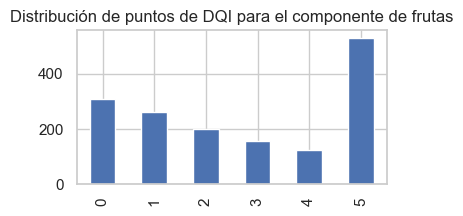

In [45]:
df_nutrients['dqi_adequacy_fruits'].value_counts().sort_index(ascending=True).plot(kind='bar', figsize=(4, 2), title='Distribución de puntos de DQI para el componente de frutas')

<AxesSubplot: title={'center': 'Distribución de puntos de DQI para el componente de verduras'}>

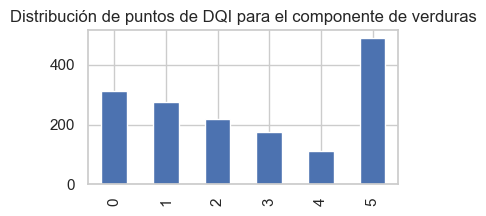

In [46]:
df_nutrients['dqi_adequacy_vegetables'].value_counts().sort_index(ascending=True).plot(kind='bar', figsize=(4, 2), title='Distribución de puntos de DQI para el componente de verduras')

<AxesSubplot: title={'center': 'Distribución de puntos de DQI para el componente de cereales'}>

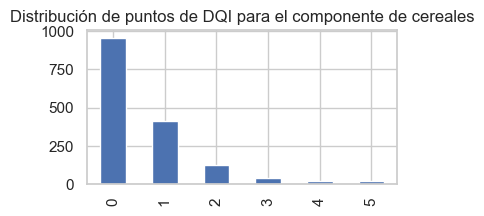

In [47]:
df_nutrients['dqi_adequacy_grains'].value_counts().sort_index(ascending=True).plot(kind='bar', figsize=(4, 2), title='Distribución de puntos de DQI para el componente de cereales')

<AxesSubplot: title={'center': 'Distribución de puntos de DQI para el componente de fibra'}>

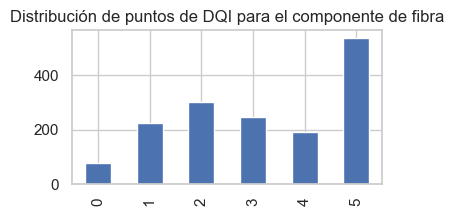

In [48]:
df_nutrients['dqi_adequacy_fiber'].value_counts().sort_index(ascending=True).plot(kind='bar', figsize=(4, 2), title='Distribución de puntos de DQI para el componente de fibra')

<AxesSubplot: title={'center': 'Distribución de puntos de DQI para el componente de proteínas'}>

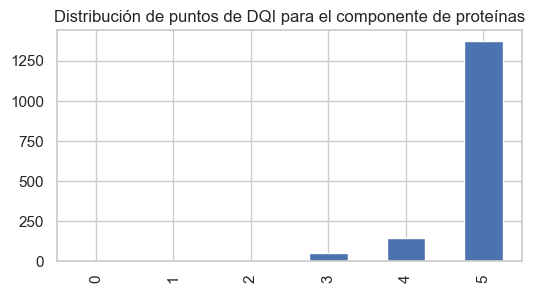

In [49]:
df_nutrients['protein_percentage'] = (df_nutrients['protein']*4).div(df_nutrients['energ_kcal'])
df_nutrients['dqi_adequacy_protein'] = df_nutrients.apply(calculate_adecucy_groups, axis=1, group='protein_percentage', reference=0.1)
df_nutrients['dqi_adequacy_protein'].value_counts().sort_index(ascending=True).plot(kind='bar', figsize=(6, 3), title='Distribución de puntos de DQI para el componente de proteínas')

Los siguientes valores se calculan con base en la cantidad de nutrientes sugeridos por cada persona según su género.

In [50]:
rda = {
    'Hombre': {
        'Calcio': 1000,
        'Hierro': 8,
        'Magnesio': 400,
        'Proteina': 56,
        'Vitamina A': 900,
        'Vitamina C': 90,
        'Vitamina D': 15,
        'Vitamina E': 15,
        'Vitamina K': 120,
        'Zinc': 11,
        'Fibra': 38
    },
    'Mujer': {
        'Calcio': 1000,
        'Hierro': 18,
        'Magnesio': 310,
        'Proteina': 46,
        'Vitamina A': 700,
        'Vitamina C': 75,
        'Vitamina D': 15,
        'Vitamina E': 15,
        'Vitamina K': 90,
        'Zinc': 8,
        'Fibra': 25
    }
}


In [51]:
df_dem_final.head()

,folio_integrante,edad,ponderador,grupo,resultado_general_entrevista,region_Centro,region_Centro Norte,region_Frontera,region_Pacifico-Norte,region_Pacífico Sur,region_Pacífico-Centro,region_Península,sexo_Mujer,estrato_Rural ( <2500 Hab ),"estrato_Urbano ( 2500-99,999 Hab)"
0,2022_01001001_01,51,8717.185479,Adolescentes y Adultos,1,False,True,False,False,False,False,False,True,False,False
1,2022_01001028_04,26,51475.173556,Adolescentes y Adultos,1,False,True,False,False,False,False,False,True,False,False
2,2022_01001034_03,12,16477.855758,Adolescentes y Adultos,1,False,True,False,False,False,False,False,False,False,False
3,2022_01001041_04,12,11801.483710,Adolescentes y Adultos,1,False,True,False,False,False,False,False,False,False,False
4,2022_01001042_01,62,7032.174356,Adolescentes y Adultos,1,False,True,False,False,False,False,False,True,False,False


In [52]:
def calculate_rda_nutritient_consumption(row,rda,rda_nutrient,food_nutrient,df_dem):
    genre = 'Mujer' if int(df_dem[df_dem['folio_integrante'] == row.name]['sexo_Mujer']) == 1 else 'Hombre'


    rda_value = rda[genre][rda_nutrient]
        
    pertentage_intake = (row[food_nutrient] / 7)/ rda_value
    if pertentage_intake >= 1:
        return 5
    elif pertentage_intake >= 0.8:
        return 4
    elif pertentage_intake >= 0.6:
        return 3
    elif pertentage_intake >= 0.4:
        return 2
    elif pertentage_intake >= 0.2:
        return 1
    else:
        return 0
    
df_nutrients['dqi_adequacy_calcium'] = df_nutrients.apply(calculate_rda_nutritient_consumption, axis=1, rda=rda, rda_nutrient='Calcio', food_nutrient='calcium',df_dem=df_dem_final)
df_nutrients['dqi_adequacy_iron'] = df_nutrients.apply(calculate_rda_nutritient_consumption, axis=1, rda=rda, rda_nutrient='Hierro', food_nutrient='iron',df_dem=df_dem_final)
df_nutrients['dqi_adequacy_vitamin_c'] = df_nutrients.apply(calculate_rda_nutritient_consumption, axis=1, rda=rda, rda_nutrient='Vitamina C', food_nutrient='vit_c',df_dem=df_dem_final)

<AxesSubplot: title={'center': 'Distribución de puntos de DQI para el componente de calcio'}>

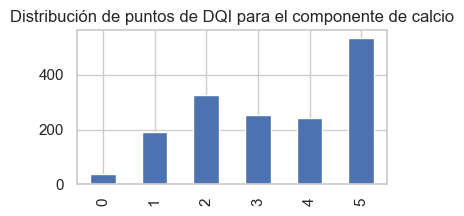

In [53]:
df_nutrients['dqi_adequacy_calcium'].value_counts().sort_index(ascending=True).plot(kind='bar', figsize=(4, 2), title='Distribución de puntos de DQI para el componente de calcio')

<AxesSubplot: title={'center': 'Distribución de puntos de DQI para el componente de hierro'}>

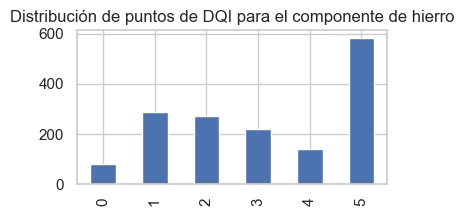

In [54]:
df_nutrients['dqi_adequacy_iron'].value_counts().sort_index(ascending=True).plot(kind='bar', figsize=(4, 2), title='Distribución de puntos de DQI para el componente de hierro')

<AxesSubplot: title={'center': 'Distribución de puntos de DQI para el componente de vitamina C'}>

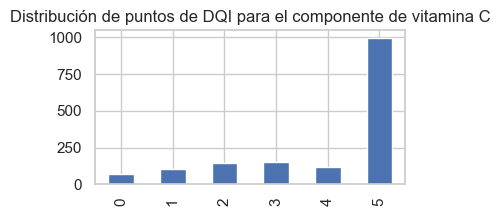

In [55]:
df_nutrients['dqi_adequacy_vitamin_c'].value_counts().sort_index(ascending=True).plot(kind='bar', figsize=(4, 2), title='Distribución de puntos de DQI para el componente de vitamina C')

<AxesSubplot: title={'center': 'Distribución de puntos de DQI para el componente de adecuación'}>

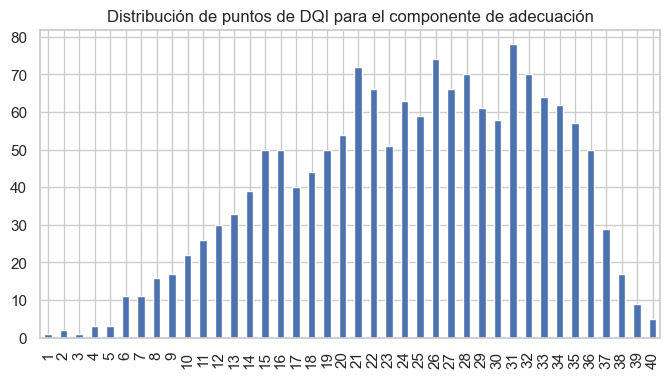

In [56]:
df_nutrients['dqi_adecuacy'] = df_nutrients['dqi_adequacy_fruits'] + df_nutrients['dqi_adequacy_vegetables'] + df_nutrients['dqi_adequacy_grains'] + \
                                df_nutrients['dqi_adequacy_fiber'] + df_nutrients['dqi_adequacy_protein'] + df_nutrients['dqi_adequacy_calcium'] + \
                                df_nutrients['dqi_adequacy_iron'] + df_nutrients['dqi_adequacy_vitamin_c']
df_nutrients['dqi_adecuacy'].value_counts().sort_index(ascending=True).plot(kind='bar', figsize=(8, 4), title='Distribución de puntos de DQI para el componente de adecuación')

# Análisis descriptivo DQI-I

Se suman todos los valores de DQI calculados previamente para tener una columna de **dqi_total** para tener el resultado total por registro. 

In [57]:
df_nutrients['dqi_total'] = df_nutrients['balance_dqi'] + df_nutrients['moderation_dqi'] + df_nutrients['dqi_adecuacy'] + df_nutrients['variety_dqi']

In [58]:
df_dqi_final_merged = df_nutrients.merge(df_dem_final, on='folio_integrante', how='left')

In [59]:
df_dqi = df_dqi_final_merged.copy()
df_dqi = df_dqi[['edad', 'ponderador', 'resultado_general_entrevista', 'region_Centro', 'region_Centro Norte',
       'region_Frontera', 'region_Pacifico-Norte', 'region_Pacífico Sur',
       'region_Pacífico-Centro', 'region_Península', 'sexo_Mujer',
       'estrato_Rural  ( <2500 Hab )', 'estrato_Urbano ( 2500-99,999 Hab)','balance_dqi', 'moderation_dqi', 'variety_dqi', 'dqi_food_groups', 'dqi_protein_sources', 'dqi_adecuacy', 'dqi_total']]
df_dqi.head()

,edad,ponderador,resultado_general_entrevista,region_Centro,region_Centro Norte,region_Frontera,region_Pacifico-Norte,region_Pacífico Sur,region_Pacífico-Centro,region_Península,sexo_Mujer,estrato_Rural ( <2500 Hab ),"estrato_Urbano ( 2500-99,999 Hab)",balance_dqi,moderation_dqi,variety_dqi,dqi_food_groups,dqi_protein_sources,dqi_adecuacy,dqi_total
0,51,8717.185479,1,False,True,False,False,False,False,False,True,False,False,0,12,17,12,5,31,60
1,1,5378.108847,1,False,True,False,False,False,False,False,False,False,False,2,15,7,6,1,26,50
2,4,4692.485672,1,False,True,False,False,False,False,False,False,False,False,0,12,9,6,3,15,36
3,26,51475.173556,1,False,True,False,False,False,False,False,True,False,False,0,9,17,12,5,32,58
4,2,6860.703803,1,False,True,False,False,False,False,False,False,False,False,2,21,17,12,5,29,69


In [60]:
## reversar one hot encoding

df_dqi['region'] = df_dqi[['region_Centro', 'region_Centro Norte', 'region_Frontera', 'region_Pacifico-Norte', 'region_Pacífico Sur', 'region_Pacífico-Centro', 'region_Península']].idxmax(axis=1)
df_dqi['estrato'] = df_dqi[['estrato_Rural  ( <2500 Hab )', 'estrato_Urbano ( 2500-99,999 Hab)']].idxmax(axis=1)
df_dqi.drop(columns=['region_Centro', 'region_Centro Norte', 'region_Frontera', 'region_Pacifico-Norte', 'region_Pacífico Sur', 'region_Pacífico-Centro', 'region_Península', 'estrato_Rural  ( <2500 Hab )', 'estrato_Urbano ( 2500-99,999 Hab)'], inplace=True)



In [61]:
# Crear una columna sexo a partir de la columna sexo_Mujer
df_dqi['sexo'] = df_dqi['sexo_Mujer'].map({True: 'Mujer', False: 'Hombre'})
df_dqi.drop(columns=['sexo_Mujer'], inplace=True)


In [62]:
df_dqi['region'] = df_dqi['region'].apply(lambda x: x.split('_')[1])
df_dqi['estrato'] = df_dqi['estrato'].apply(lambda x: x.split('_')[1])
df_dqi.head()

,edad,ponderador,resultado_general_entrevista,balance_dqi,moderation_dqi,variety_dqi,dqi_food_groups,dqi_protein_sources,dqi_adecuacy,dqi_total,region,estrato,sexo
0,51,8717.185479,1,0,12,17,12,5,31,60,Centro Norte,Rural ( <2500 Hab ),Mujer
1,1,5378.108847,1,2,15,7,6,1,26,50,Centro Norte,Rural ( <2500 Hab ),Hombre
2,4,4692.485672,1,0,12,9,6,3,15,36,Centro Norte,Rural ( <2500 Hab ),Hombre
3,26,51475.173556,1,0,9,17,12,5,32,58,Centro Norte,Rural ( <2500 Hab ),Mujer
4,2,6860.703803,1,2,21,17,12,5,29,69,Centro Norte,Rural ( <2500 Hab ),Hombre


Se filtran únicamente los adultos y personas que tuvieron una encuesta completa

In [63]:
df_dqi = df_dqi[(df_dqi['edad'] >= 18) & (df_dqi['edad'] < 65) & (df_dqi['resultado_general_entrevista'] == 1)]

In [64]:
# normalizar ponderacion
df_dqi['ponderador'] = df_dqi['ponderador'].div(df_dqi['ponderador'].sum())


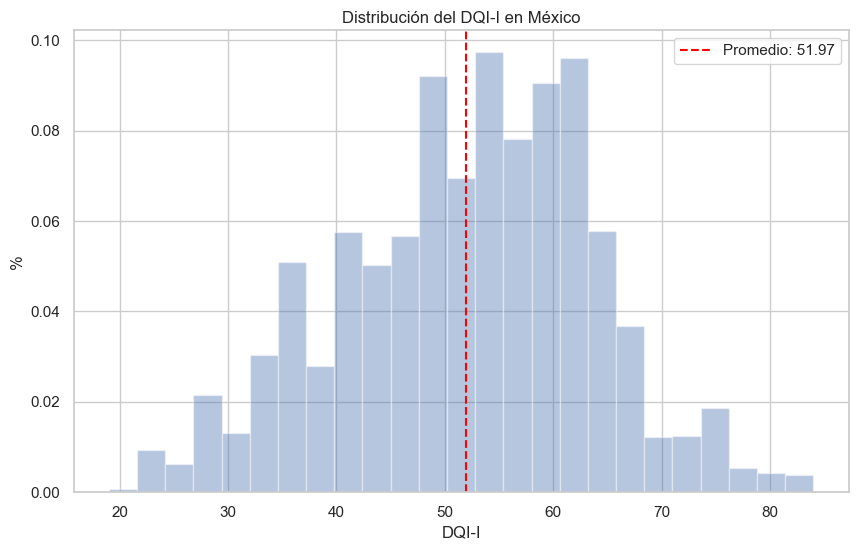

In [65]:
weighted_mean = (df_dqi['dqi_total'] * df_dqi['ponderador']).sum() / df_dqi['ponderador'].sum()
plt.figure(figsize=(10, 6))
sns.distplot(df_dqi.dqi_total, bins=25, 
    hist_kws={'weights':df_dqi.ponderador}, norm_hist=False,kde=False)
plt.axvline(weighted_mean, color='red', linestyle='--', label=f'Promedio: {weighted_mean:.2f}')
plt.title("Distribución del DQI-I en México")
plt.xlabel("DQI-I")
plt.ylabel("%")
plt.legend()
plt.show()

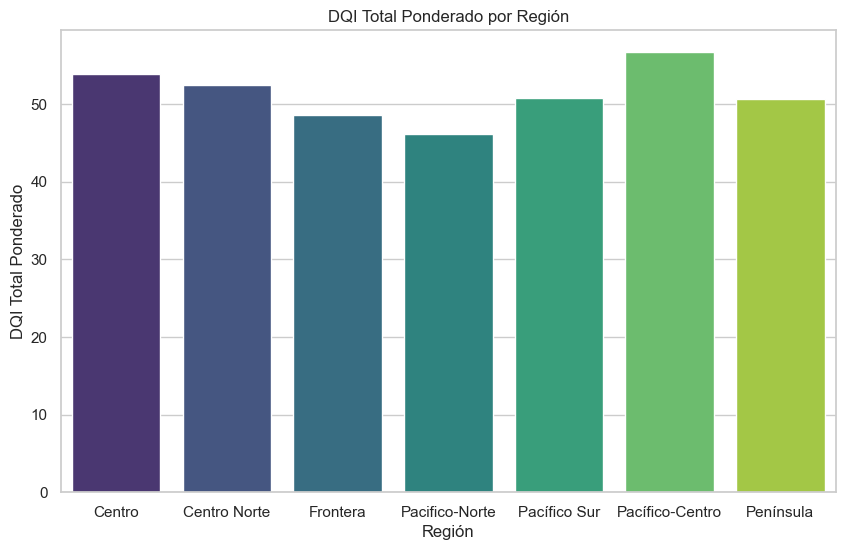

In [66]:
# Calcular el DQI total ponderado por región
weighted_dqi_by_region = df_dqi.groupby('region').apply(
    lambda x: (x['dqi_total'] * x['ponderador']).sum() / x['ponderador'].sum()
).reset_index(name='weighted_dqi_total')

# Crear el gráfico de barras
plt.figure(figsize=(10, 6))
sns.barplot(data=weighted_dqi_by_region, x='region', y='weighted_dqi_total', palette="viridis")
plt.title("DQI Total Ponderado por Región")
plt.xlabel("Región")
plt.ylabel("DQI Total Ponderado")
plt.show()

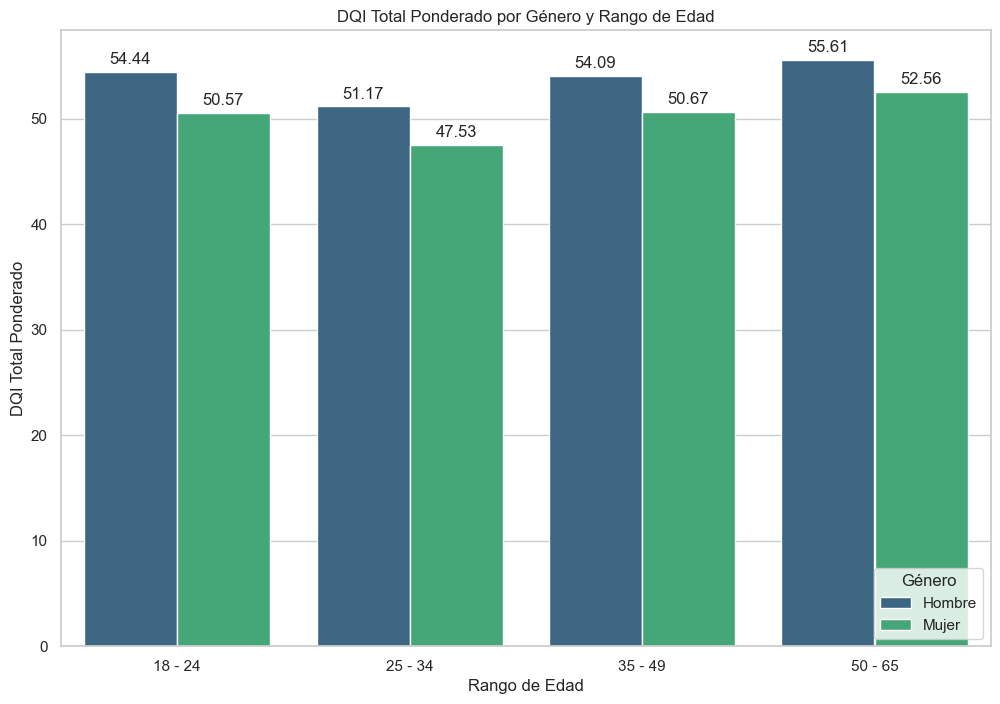

In [67]:
# Crear rangos de edad
labels = ['18 - 24', '25 - 34', '35 - 49', '50 - 65']
bins = [18, 25, 35, 50, 65]
df_dqi['edad_rango'] = pd.cut(df_dqi['edad'], bins=bins, labels=labels, right=False)

# Calcular el DQI total ponderado por género y rango de edad
weighted_dqi_by_gender_age = df_dqi.groupby(['sexo', 'edad_rango']).apply(
    lambda x: (x['dqi_total'] * x['ponderador']).sum() / x['ponderador'].sum()
).reset_index(name='weighted_dqi_total')

# Crear el gráfico de barras
plt.figure(figsize=(12, 8))
ax = sns.barplot(data=weighted_dqi_by_gender_age, x='edad_rango', y='weighted_dqi_total', hue='sexo', palette="viridis")
plt.title("DQI Total Ponderado por Género y Rango de Edad")
plt.xlabel("Rango de Edad")
plt.ylabel("DQI Total Ponderado")
plt.legend(title="Género", loc='lower right')

# Añadir etiquetas de datos
for p in ax.patches:
    ax.annotate(format(p.get_height(), '.2f'), 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha = 'center', va = 'center', 
                xytext = (0, 9), 
                textcoords = 'offset points')

plt.show()

## Ajustes finales *df_nutrients* para modelos

Ahora que se tienen todas las variables que forman el cálculo DQI integradas en un mismo dataframe, en este caso df_nutrients, se tomarán estos valores para el análisis con los modelos para las siguientes etapas. 

El df_nutrients cuenta con todos los datos de calculos de DQI

In [68]:
df_nutrients.columns

Index(['energ_kcal', 'carbohydrt', 'lipid_tot', 'protein', 'fiber_td',
       'calcium', 'iron', 'ironhem', 'ironnohem', 'zinc', 'vit_c', 'thiamin',
       'riboflavin', 'niacin', 'panto_acid', 'vit_b6', 'folic_acid',
       'food_folate', 'folate_dfe', 'vit_b12', 'vit_a_rae', 'vit_e',
       'vit_d_iu', 'vit_k', 'fa_sat', 'fa_mono', 'fa_poly', 'chole', 'sodio',
       'carbohydrt_ratio', 'lipid_tot_ratio', 'protein_ratio',
       'macronutrients_dqi', 'poly_ratio', 'mono_ratio', 'fatty_acids_dqi',
       'balance_dqi', 'empty_calories', 'porc_empty_calories',
       'empty_calories_dqi', 'fat_percentage', 'fa_sat_percentage',
       'total_fat_dqi', 'saturated_fat_dqi', 'cholesterol_dqi', 'sodium_dqi',
       'moderation_dqi', 'Aceites y Grasas', 'Azucares', 'Cereales', 'Frutas',
       'Lacteos/Frijol', 'Misceláneos', 'Proteina', 'Verduras',
       'dqi_food_groups', 'subgrupo de Carne', 'subgrupo de Frijoles',
       'subgrupo de Huevo', 'subgrupo de Lacteos', 'subgrupo de Pescado',

In [69]:
# Guardar el dataframe con los puntajes de DQI
df_nutrients.to_csv('./Data/Processed/df_nutrients_dqi.csv', sep=';', index=True)

Adicionalmente se agregaran los datos demograficos para tener un dataframe completo con el cual trabajar para cualquier análisis con modelos

In [70]:
df_nutrients.head()

,energ_kcal,carbohydrt,lipid_tot,protein,fiber_td,calcium,iron,ironhem,ironnohem,zinc,...,dqi_adequacy_vegetables,dqi_adequacy_grains,dqi_adequacy_fiber,protein_percentage,dqi_adequacy_protein,dqi_adequacy_calcium,dqi_adequacy_iron,dqi_adequacy_vitamin_c,dqi_adecuacy,dqi_total
folio_integrante,,,,,,,,,,,,,,,,,,,,,
2022_01001001_01,7942.748400,1053.768410,316.780600,299.807050,130.912750,7933.4173,67.57558,2.0320,38.68308,53.623690,...,5,0,4,0.150984,5,5,2,5,31,60
2022_01001007_04,10188.514200,1552.413200,317.152900,356.773300,85.063300,10420.9000,79.81630,2.1140,39.77830,74.473800,...,2,0,3,0.140069,5,5,5,5,26,50
2022_01001016_13,5907.336000,664.798800,285.823600,190.180800,47.036500,3528.2880,39.58570,1.1180,19.63820,33.327000,...,0,1,1,0.128776,5,2,3,2,15,36
2022_01001028_04,11984.458475,1578.962350,451.073700,471.864675,172.392750,7778.0270,85.94970,5.2282,66.92500,68.392875,...,5,0,5,0.157492,5,5,3,5,32,58
2022_01001028_06,5802.271275,870.090775,185.723627,202.725924,122.760165,3337.8500,43.15056,0.7647,36.26686,30.666847,...,5,0,4,0.139756,5,2,3,5,29,69


In [71]:
# Filtrar columnas que contienen la palabra "dqi" en el nombre de la columna
dqi_columns = [col for col in df_nutrients.columns if "dqi" in col]
print(dqi_columns)


['macronutrients_dqi', 'fatty_acids_dqi', 'balance_dqi', 'empty_calories_dqi', 'total_fat_dqi', 'saturated_fat_dqi', 'cholesterol_dqi', 'sodium_dqi', 'moderation_dqi', 'dqi_food_groups', 'dqi_protein_sources', 'variety_dqi', 'dqi_adequacy_fruits', 'dqi_adequacy_vegetables', 'dqi_adequacy_grains', 'dqi_adequacy_fiber', 'dqi_adequacy_protein', 'dqi_adequacy_calcium', 'dqi_adequacy_iron', 'dqi_adequacy_vitamin_c', 'dqi_adecuacy', 'dqi_total']


A continuación se hace el merge entre el df_nutrients y df_dem_final para tener un df resultante llamado df_dqi_final el cual tiene datos demográficos, calculos dqi, nutrientes y su index son los folios de los registros. Este df_dqi_final nos servirá para los pasos siguientes de análisis con modelos. 

In [72]:
# Filtra el DataFrame para conservar solo las columnas de puntajes DQI
df_nutrients_filtered = df_nutrients[dqi_columns]

# Resetear el índice de df_nutrients_filtered para que folio_integrante sea una columna
df_nutrients_reset = df_nutrients_filtered.reset_index()
df_nutrients_reset.head()

,folio_integrante,macronutrients_dqi,fatty_acids_dqi,balance_dqi,empty_calories_dqi,total_fat_dqi,saturated_fat_dqi,cholesterol_dqi,sodium_dqi,moderation_dqi,...,dqi_adequacy_fruits,dqi_adequacy_vegetables,dqi_adequacy_grains,dqi_adequacy_fiber,dqi_adequacy_protein,dqi_adequacy_calcium,dqi_adequacy_iron,dqi_adequacy_vitamin_c,dqi_adecuacy,dqi_total
0,2022_01001001_01,0,0,0,0,0,0,6,6,12,...,5,5,0,4,5,5,2,5,31,60
1,2022_01001007_04,2,0,2,0,3,0,6,6,15,...,1,2,0,3,5,5,5,5,26,50
2,2022_01001016_13,0,0,0,0,0,0,6,6,12,...,1,0,1,1,5,2,3,2,15,36
3,2022_01001028_04,0,0,0,3,0,0,0,6,9,...,4,5,0,5,5,5,3,5,32,58
4,2022_01001028_06,2,0,2,3,3,3,6,6,21,...,5,5,0,4,5,2,3,5,29,69


In [73]:
# Realizar la unión con df_dem_final_filtered usando folio_integrante como clave
df_dqi_merged = df_nutrients_reset.merge(df_dem_final, on='folio_integrante', how='left')

# Establecer folio_integrante como índice en el DataFrame resultante
df_dqi_Y_demogra = df_dqi_merged.set_index('folio_integrante')
df_dqi_Y_demogra.head()


,macronutrients_dqi,fatty_acids_dqi,balance_dqi,empty_calories_dqi,total_fat_dqi,saturated_fat_dqi,cholesterol_dqi,sodium_dqi,moderation_dqi,dqi_food_groups,...,region_Centro,region_Centro Norte,region_Frontera,region_Pacifico-Norte,region_Pacífico Sur,region_Pacífico-Centro,region_Península,sexo_Mujer,estrato_Rural ( <2500 Hab ),"estrato_Urbano ( 2500-99,999 Hab)"
folio_integrante,,,,,,,,,,,,,,,,,,,,,
2022_01001001_01,0,0,0,0,0,0,6,6,12,12,...,False,True,False,False,False,False,False,True,False,False
2022_01001007_04,2,0,2,0,3,0,6,6,15,6,...,False,True,False,False,False,False,False,False,False,False
2022_01001016_13,0,0,0,0,0,0,6,6,12,6,...,False,True,False,False,False,False,False,False,False,False
2022_01001028_04,0,0,0,3,0,0,0,6,9,12,...,False,True,False,False,False,False,False,True,False,False
2022_01001028_06,2,0,2,3,3,3,6,6,21,12,...,False,True,False,False,False,False,False,False,False,False


In [74]:
df_dqi_Y_demogra = df_dqi_Y_demogra[(df_dqi_Y_demogra['edad'] >= 18) & (df_dqi_Y_demogra['edad'] < 65) & (df_dqi_Y_demogra['resultado_general_entrevista'] == 1)]
df_dqi_Y_demogra.shape


(638, 36)

In [75]:
df_dqi_final = df_dqi_Y_demogra.copy()
df_dqi_final.head()

,macronutrients_dqi,fatty_acids_dqi,balance_dqi,empty_calories_dqi,total_fat_dqi,saturated_fat_dqi,cholesterol_dqi,sodium_dqi,moderation_dqi,dqi_food_groups,...,region_Centro,region_Centro Norte,region_Frontera,region_Pacifico-Norte,region_Pacífico Sur,region_Pacífico-Centro,region_Península,sexo_Mujer,estrato_Rural ( <2500 Hab ),"estrato_Urbano ( 2500-99,999 Hab)"
folio_integrante,,,,,,,,,,,,,,,,,,,,,
2022_01001001_01,0,0,0,0,0,0,6,6,12,12,...,False,True,False,False,False,False,False,True,False,False
2022_01001028_04,0,0,0,3,0,0,0,6,9,12,...,False,True,False,False,False,False,False,True,False,False
2022_01001042_01,0,0,0,3,0,0,0,6,9,15,...,False,True,False,False,False,False,False,True,False,False
2022_01001075_02,0,0,0,0,0,0,0,6,6,9,...,False,True,False,False,False,False,False,True,False,False
2022_01001081_02,0,0,0,0,0,0,0,3,3,15,...,False,True,False,False,False,False,False,True,False,False


In [76]:
df_dqi_final.shape

(638, 36)

In [77]:
df_dqi_final.head()
non_null_records = df_dqi_final.dropna().shape[0]
print(non_null_records)
total_records = df_dqi_final.shape[0]
print(f"Total records: {total_records}")
print(f"Non-null records: {non_null_records}")

638
Total records: 638
Non-null records: 638


En lo siguiente se genera el archivo df_dqi_final a un archivo csv separado por ; guardado en la carpeta Processed dentro del proyecto. También, se pasa el index con los folios porque son importantes para el análisis. 

In [78]:
df_dqi_final.to_csv('./Data/Processed/df_dqi_final.csv', sep=';', index=True)